
BUSINESS UNDERSTANDING

Context
Everybody nowadays is mindful of what they eat. Counting calories and reducing fat intake is the number one advice given by all dieticians and nutritionists. Therefore, we need to know what foods are rich in what nutrients, don't we?

Content
The dataset contains a csv file with more than 300 foods each with the amount of Calories, Fats, Proteins, Saturated Fats, Carbohydrates, Fibers labelled for each food. Also, the foods are also categorised into various groups like Desserts, Vegetables, Fruits etc.
Note: "t" indicates that only a trace amount is available(miniscule)

Acknowledgements
References: https://en.wikipedia.org/wiki/Table_of_food_nutrients

OBJECTIVE/GOAL
- Use PCA to discover which nutrients explain most of the variation across foods and whether foods with similar nutritional profiles group together

LOAD LIBRARIES

In [32]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_rainbow
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.regressionplots import plot_ccpr
from statsmodels.nonparametric.smoothers_lowess import lowess

LOAD DATASET

In [33]:
nutrients_df=pd.read_csv("data/nutrients_csvfile.csv")

In [34]:
records, features = nutrients_df.shape
output = f"The data set has {records} records and {features} features"
print(output)

The data set has 335 records and 10 features


In [35]:
nutrients_df.head()

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
0,Cows' milk,1 qt.,976,660,32,40,36,0,48,Dairy products
1,Milk skim,1 qt.,984,360,36,t,t,0,52,Dairy products
2,Buttermilk,1 cup,246,127,9,5,4,0,13,Dairy products
3,"Evaporated, undiluted",1 cup,252,345,16,20,18,0,24,Dairy products
4,Fortified milk,6 cups,"1,419","1,373",89,42,23,1.4,119,Dairy products


In [36]:
nutrients_df.tail()

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
330,Fruit-flavored soda,12 oz.,346,161,0,0,0,0,42,"Drinks,Alcohol, Beverages"
331,Ginger ale,12 oz.,346,105,0,0,0,0,28,"Drinks,Alcohol, Beverages"
332,Root beer,12 oz.,346,140,0,0,0,0,35,"Drinks,Alcohol, Beverages"
333,Coffee,1 cup,230,3,t,0,0,0,1,"Drinks,Alcohol, Beverages"
334,Tea,1 cup,230,4,0,t,0,0,1,"Drinks,Alcohol, Beverages"


In [37]:
nutrients_df.dtypes

Food        str
Measure     str
Grams       str
Calories    str
Protein     str
Fat         str
Sat.Fat     str
Fiber       str
Carbs       str
Category    str
dtype: object

insight:nutrition columns should be numeric before analysis or PCA.

In [38]:
# Convert numeric columns
numeric_cols = ['Grams', 'Calories', 'Protein',
                'Fat', 'Sat.Fat', 'Fiber', 'Carbs']

for col in numeric_cols:
    nutrients_df[col] = pd.to_numeric(nutrients_df[col], errors='coerce')

# Check datatypes
print(nutrients_df.dtypes)

Food            str
Measure         str
Grams       float64
Calories    float64
Protein     float64
Fat         float64
Sat.Fat     float64
Fiber       float64
Carbs       float64
Category        str
dtype: object


In [39]:
print(nutrients_df.isna().sum())

Food          0
Measure       0
Grams         1
Calories      5
Protein      39
Fat         116
Sat.Fat      17
Fiber        27
Carbs        13
Category      0
dtype: int64


In [40]:
nutrients_df = nutrients_df.fillna(nutrients_df.mean(numeric_only=True))
nutrients_df

,Food,Measure,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs,Category
0,Cows' milk,1 qt.,976.000000,660.000000,32.000000,40.000000,36.000000,0.0,48.0,Dairy products
1,Milk skim,1 qt.,984.000000,360.000000,36.000000,13.063927,6.742138,0.0,52.0,Dairy products
2,Buttermilk,1 cup,246.000000,127.000000,9.000000,5.000000,4.000000,0.0,13.0,Dairy products
3,"Evaporated, undiluted",1 cup,252.000000,345.000000,16.000000,20.000000,18.000000,0.0,24.0,Dairy products
4,Fortified milk,6 cups,139.392216,179.806061,89.000000,42.000000,23.000000,1.4,119.0,Dairy products
...,...,...,...,...,...,...,...,...,...,...
330,Fruit-flavored soda,12 oz.,346.000000,161.000000,0.000000,0.000000,0.000000,0.0,42.0,"Drinks,Alcohol, Beverages"
331,Ginger ale,12 oz.,346.000000,105.000000,0.000000,0.000000,0.000000,0.0,28.0,"Drinks,Alcohol, Beverages"
332,Root beer,12 oz.,346.000000,140.000000,0.000000,0.000000,0.000000,0.0,35.0,"Drinks,Alcohol, Beverages"
333,Coffee,1 cup,230.000000,3.000000,9.702703,0.000000,0.000000,0.0,1.0,"Drinks,Alcohol, Beverages"


In [41]:
nutrients_df.describe()

,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs
count,335.000000,335.000000,335.000000,335.000000,335.000000,335.000000,335.000000
mean,139.392216,179.806061,9.702703,13.063927,6.742138,2.576656,25.990994
std,119.754910,154.475233,17.457719,18.793800,18.409258,16.039335,35.478707
min,11.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000
25%,60.000000,75.000000,2.000000,5.000000,0.000000,0.000000,6.000000
50%,108.000000,135.000000,5.000000,13.063927,0.000000,0.500000,18.000000
75%,200.000000,245.000000,12.000000,13.063927,7.500000,1.650000,30.500000
max,984.000000,992.000000,232.000000,233.000000,234.000000,235.000000,236.000000


In [42]:
nutrients_df['Protein'] = nutrients_df['Protein'].replace(-1, np.nan) ##Negative nutrients are impossible.

In [43]:
nutrients_df.describe()

,Grams,Calories,Protein,Fat,Sat.Fat,Fiber,Carbs
count,335.000000,335.000000,334.000000,335.000000,335.000000,335.000000,335.000000
mean,139.392216,179.806061,9.734747,13.063927,6.742138,2.576656,25.990994
std,119.754910,154.475233,17.474043,18.793800,18.409258,16.039335,35.478707
min,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,60.000000,75.000000,2.000000,5.000000,0.000000,0.000000,6.000000
50%,108.000000,135.000000,5.000000,13.063927,0.000000,0.500000,18.000000
75%,200.000000,245.000000,12.000000,13.063927,7.500000,1.650000,30.500000
max,984.000000,992.000000,232.000000,233.000000,234.000000,235.000000,236.000000


insight:
1. Grams
- Average serving size is about 139g
- Minimum is 11g while maximum is 984g
- High standard deviation of 119.75 shows serving sizes vary widely across foods
- Distribution is likely right-skewed because of very large serving sizes
2. Calories
- Mean is at 179.8,Median at 135 Since the mean is greater than the median, Calorie distribution is positively skewed
- Some foods are extremely calorie-dense
- Most foods are moderately caloric, but a few high-calorie foods create outliers.
3. fiber
- Most foods contain low fiber, but some foods have very high values.
- Fiber is sparse across many foods but highly concentrated in certain items.
4. Carbs
- a mean of 25.99g,Median of 18g and a Maximum of 236g
- strong right skewness
- Presence of high-carb foods
- Carbohydrate levels vary significantly across food categories.
5. saturated fat
-Mean: 6.74g and Max of 234g
- Large gap between mean and median suggests Many foods contain little/no saturated fat
- A few foods have extremely high saturated fat
- Saturated fat distribution is heavily right-skewed.
6. protein
- a Mean of 9.73g, Median of 5g and Maximum of 232g
- Most foods contain low-to-moderate protein, Some foods are highly protein-dense
- Distribution is positively skewed
- Protein-rich foods form a small potion of the dataset.

array([[<Axes: title={'center': 'Grams'}>,
        <Axes: title={'center': 'Calories'}>,
        <Axes: title={'center': 'Protein'}>],
       [<Axes: title={'center': 'Fat'}>,
        <Axes: title={'center': 'Sat.Fat'}>,
        <Axes: title={'center': 'Fiber'}>],
       [<Axes: title={'center': 'Carbs'}>, <Axes: >, <Axes: >]],
      dtype=object)

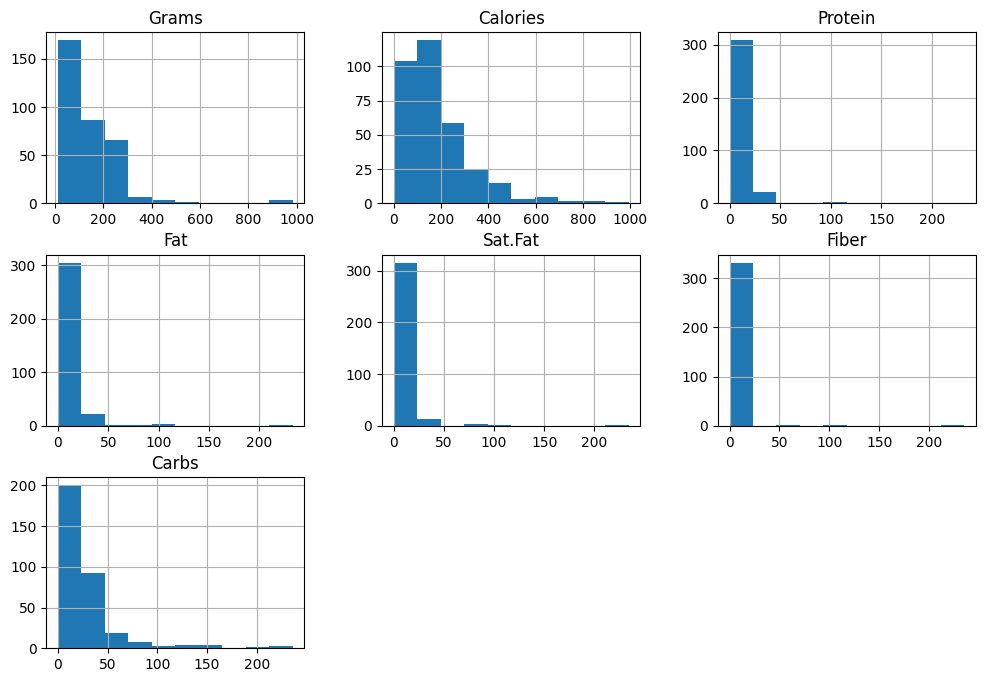

In [46]:
nutrients_df.hist(figsize=(12,8))

<Axes: >

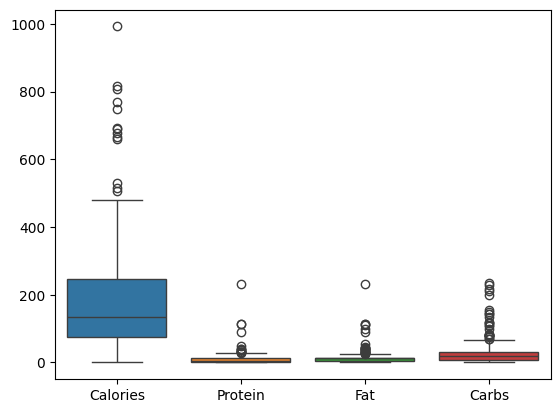

In [45]:
sns.boxplot(data=nutrients_df[['Calories','Protein','Fat','Carbs']])

<Axes: xlabel='Calories', ylabel='Density'>

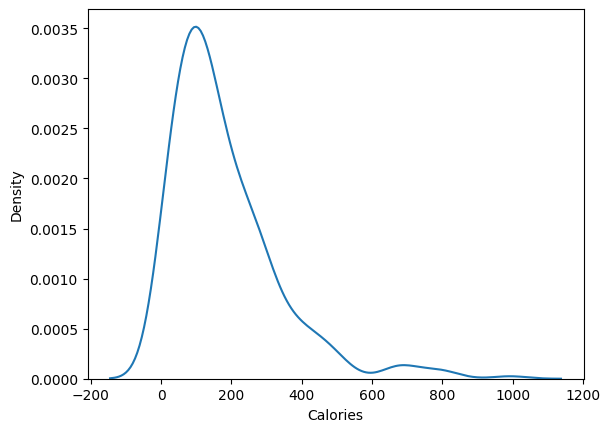

In [48]:
sns.kdeplot(nutrients_df['Calories']) ##To observe skewness:

PCA

In [65]:
nutrients_df = nutrients_df.dropna()

In [67]:
print(nutrients_df.isnull().sum())

Food        0
Measure     0
Grams       0
Calories    0
Protein     0
Fat         0
Sat.Fat     0
Fiber       0
Carbs       0
Category    0
dtype: int64


In [69]:
##FEATURE SELECTION
features = ['Calories', 'Protein', 'Fat',
            'Sat.Fat', 'Fiber', 'Carbs']

X = nutrients_df[features]

In [70]:
## STANDARDIZATION
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [71]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(principal_components,
                      columns=['PC1', 'PC2'])

pca_df['Category'] = nutrients_df['Category']

In [72]:
print(pca.explained_variance_ratio_)

[0.61347015 0.20025608]


insight:
PC1 = 0.6135  explains about 61.35% of the variance
PC2 = 0.2003  explains about 20.03% of the variance

In [73]:
sum(pca.explained_variance_ratio_)

np.float64(0.8137262269771172)

-  first two components captured over 81% of the nutritional variation in the dataset, indicating an effective dimensionality reduction.
- Total retained information approximately 81.37%
- This is a very good PCA reduction.

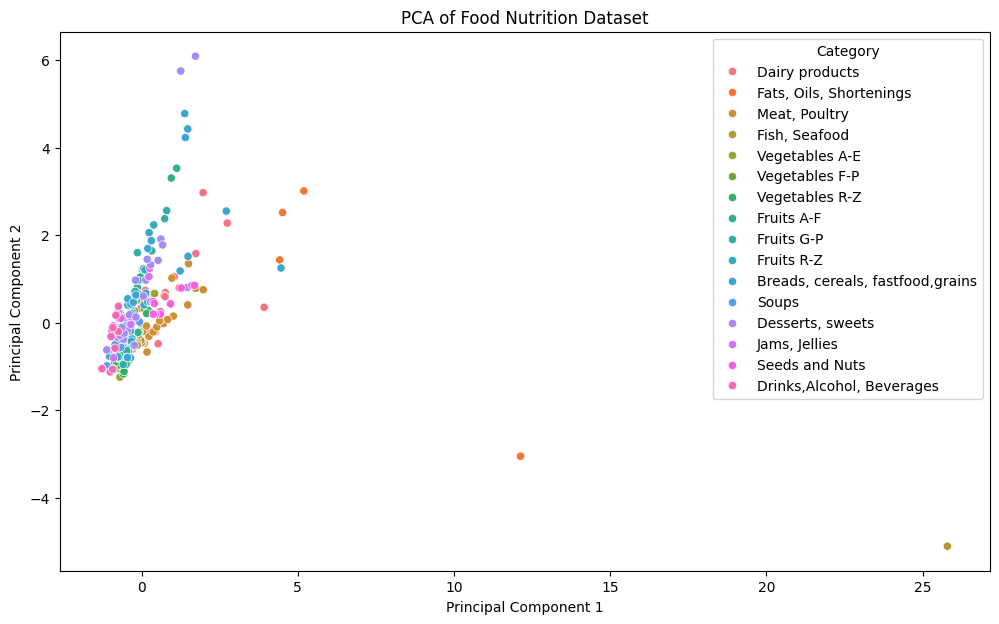

In [74]:
plt.figure(figsize=(12,7))

sns.scatterplot(data=pca_df,
                x='PC1',
                y='PC2',
                hue='Category')

plt.title('PCA of Food Nutrition Dataset')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

Food Grouping Patterns
- The PCA scatter plot shows that foods with similar nutritional compositions tended to cluster together.
- Dairy products clustering together due to similar fat and protein content
- Beverage products clustering due to low protein and fat values
- High-protein foods grouping separately from high-carbohydrate foods

In [ ]:
##Feature Contributions (Loadings) This shows which nutrients influence each principal component.
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features
)

print(loadings)

               PC1       PC2
Calories  0.196914  0.771163
Protein   0.458227 -0.187630
Fat       0.472722 -0.071891
Sat.Fat   0.486816 -0.094786
Fiber     0.464014 -0.280937
Carbs     0.274752  0.526332


insight:
- PC1 has strong positive contributions from:
Saturated Fat → 0.487
Fat → 0.473
Fiber → 0.464
Protein → 0.458
-  PC1 mainly represents the Nutritional Density Component,Foods with high PC1 values are likely:High-fat foods,Protein-rich foods,Fiber-rich foods,Dense nutritional foods

- PC2 is dominated by Calories at 0.771 and Carbs at 0.526
- Negative contributions:Fiber at -0.281 and  Protein at -0.188
- This suggests PC2 represents the Energy / Carbohydrate Component,Foods with high PC2 values are likely High-calorie foods, High-carb foods, Sugary or energy-dense foods
- Foods with low PC2 values may be Higher protein,Higher fiber and More nutrient-dense rather than calorie-dense

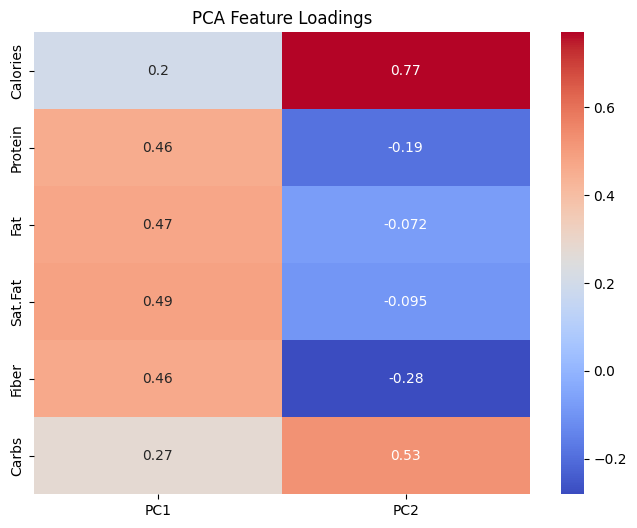

In [76]:
plt.figure(figsize=(8,6))

sns.heatmap(loadings,
            annot=True,
            cmap='coolwarm')

plt.title('PCA Feature Loadings')

plt.show()

conclusion

The PCA analysis successfully reduced the nutritional dataset into two major dimensions that explained most of the variation across foods.

- Protein, fat, saturated fat, and fiber were the strongest contributors to nutritional variation
- Calories and carbohydrates formed a separate energy-related dimension
- Foods with similar nutritional profiles grouped together in the PCA space
- The first two principal components retained over 81% of the dataset information, indicating strong dimensionality reduction performance